# 03 | Ekstraksi Fitur NLP: VADER, Loughran-McDonald, TF-IDF

**Input:** `data/split/{train,val,test}.csv`, `data/interim/articles_aligned.csv`  
**Output (folder `data/features/`):**
- `features_{train,val,test}.csv`: Fitur sentimen harian + SVD-TF-IDF + target
- `tfidf_body_{split}.npz`, `tfidf_title_{split}.npz`  Matriks TF-IDF sparse (baris sejajar dengan `features_{split}.csv`)
- `artifacts/`: Vectorizer & SVD hasil fit pada train

### Rancangan fitur
| Kelompok | Level hitung | Catatan |
|---|---|---|
| **VADER** | per artikel (judul, dan rata-rata per kalimat isi) → agregat harian | VADER dirancang untuk teks pendek, jadi isi artikel dipecah per kalimat lalu dirata-rata |
| **TF-IDF** | per hari (gabungan teks hari itu) | Vectorizer **hanya difit pada train**. Judul dan isi dipisah karena sinyalnya berbeda. Ditambah reduksi SVD agar bisa dipakai model dense |

<!-- | **Loughran-McDonald** | per artikel (isi & judul) → agregat harian | Kamus khusus keuangan: positif, negatif, *uncertainty*, *litigious*, *constraining*. Positif yang didahului negasi dihitung negatif | -->

In [1]:
import re, joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

pd.set_option("display.width", 170)
pd.set_option("display.max_columns", 50)

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "requirements.txt").exists():
            return candidate
    raise RuntimeError(
        "Repo root tidak ditemukan. Jalankan notebook dari dalam repo "
        "nlp-trio-bertiga (folder manapun di dalamnya)."
    )

ROOT = _find_repo_root(Path.cwd())
DATA = ROOT / "data"
OUT = DATA / "features"
(OUT / "artifacts").mkdir(parents=True, exist_ok=True)

C:\Users\Mikail Achmad\AppData\Local\Temp\ipykernel_41972\3309435320.py:7: UserWarning: A NumPy version >=1.23.5 and <2.5.0 is required for this version of SciPy (detected version 2.5.3)
  import scipy.sparse as sp


## 1. Muat data & petakan artikel ke split

In [2]:
train = pd.read_csv(DATA / "splits" / "train.csv", parse_dates=["date"])
val = pd.read_csv(DATA / "splits" / "val.csv", parse_dates=["date"])
test = pd.read_csv(DATA / "splits" / "test.csv", parse_dates=["date"])
for d in (train, val, test):
    d[["text_title", "text_body"]] = d[["text_title", "text_body"]].fillna("")

split_map = pd.read_csv(DATA / "splits" / "daily_with_split.csv", parse_dates=["date"])[["date", "split"]]

arts = pd.read_csv(DATA / "interim" / "articles_aligned.csv", parse_dates=["trading_date", "publish_wib"])
arts = arts.merge(split_map, left_on="trading_date", right_on="date", how="inner").drop(columns="date")
arts[["title", "body"]] = arts[["title", "body"]].fillna("")
print("Artikel yang dipakai per split (artikel di hari embargo / di luar rentang otomatis terbuang):")
print(arts["split"].value_counts())

Artikel yang dipakai per split (artikel di hari embargo / di luar rentang otomatis terbuang):
split
train    100
val       15
test      13
Name: count, dtype: int64


## 2. VADER

- **Judul:** skor `compound` langsung.
- **Isi:** dipecah per kalimat, lalu `compound` dirata-rata. Ditambah porsi kalimat negatif/positif.

In [3]:
sia = SentimentIntensityAnalyzer()

def split_sentences(text):
    parts = re.split(r"(?<=[.!?])\s+|\n+", str(text))
    return [p.strip() for p in parts if len(p.strip()) > 2]

def vader_title(text):
    return sia.polarity_scores(str(text))["compound"]

def vader_body(text):
    sents = split_sentences(text)
    if not sents:
        return {"vader_body_mean": 0.0, "vader_body_neg_share": 0.0, "vader_body_pos_share": 0.0}
    comp = np.array([sia.polarity_scores(s)["compound"] for s in sents])
    return {
        "vader_body_mean": comp.mean(),
        "vader_body_neg_share": (comp <= -0.05).mean(),
        "vader_body_pos_share": (comp >= 0.05).mean(),
    }

arts["vader_title"] = arts["title"].map(vader_title)
vb = pd.DataFrame([vader_body(t) for t in arts["body"]], index=arts.index)
arts = pd.concat([arts, vb], axis=1)
arts[["title", "vader_title", "vader_body_mean", "vader_body_neg_share"]].head()

,title,vader_title,vader_body_mean,vader_body_neg_share
0,China's health-care sector could be Beijing's ...,0.0000,0.165157,0.100000
1,Guinea coup rattles iron ore and bauxite marke...,-0.3400,-0.006200,0.310345
2,"Biden, Xi discuss avoiding confrontation in se...",-0.5719,0.081052,0.160000
3,EU chief calls for more military independence ...,0.0000,0.108124,0.212121
4,Op-ed: Will China's President Xi's big bet pay...,-0.1027,0.266714,0.135135


<!-- ## 3. Loughran-McDonald

Kamus dibaca langsung dari file Master Dictionary.  
Urutan pencarian:
1. `data/external/` (taruh file resmi dari [Notre Dame SRAF](https://sraf.nd.edu/loughranmcdonald-master-dictionary/) di sini — **disarankan** untuk laporan),
2. file `LM.csv` yang ikut terpasang bersama paket `pysentiment2` (`pip install pysentiment2`).

Skor yang dihitung (dari jumlah token isi/judul): proporsi kata `positive`, `negative`, `uncertainty`, `litigious`, `constraining`, serta **net sentiment** = (pos − neg) / (pos + neg). -->

In [4]:
# def find_lm_file():
#     ext = DATA / "external"
#     if ext.exists():
#         for p in ext.glob("*"):
#             if p.suffix.lower() == ".csv" and ("loughran" in p.name.lower() or p.name.lower() == "lm.csv"):
#                 return p
#     try:
#         import pysentiment2, os
#         p = Path(os.path.dirname(pysentiment2.__file__)) / "static" / "LM.csv"
#         if p.exists():
#             return p
#     except ImportError:
#         pass
#     raise FileNotFoundError("Kamus LM tidak ditemukan. Letakkan Master Dictionary di data/external/ atau `pip install pysentiment2`.")

# lm_path = find_lm_file()
# print("Kamus LM:", lm_path)
# lm = pd.read_csv(lm_path)

# # kolom kategori berisi tahun lalu ubah jadi set kata
# LM_SETS = {
#     cat: set(lm.loc[lm[cat] > 0, "Word"].str.upper())
#     for cat in ["Positive", "Negative", "Uncertainty", "Litigious", "Constraining"]
# }
# print({k: len(v) for k, v in LM_SETS.items()})

In [5]:
# NEGATORS = {"NO", "NOT", "NONE", "NEITHER", "NEVER", "NOBODY", "NOTHING", "NOR"}
# TOKEN_RE = re.compile(r"[A-Za-z]+")

# def lm_scores(text, prefix):
#     toks = [t.upper() for t in TOKEN_RE.findall(str(text))]
#     n = len(toks)
#     if n == 0:
#         return {f"{prefix}_{k}": 0.0 for k in ["pos", "neg", "unc", "lit", "con", "net"]}
#     pos = neg = unc = lit = con = 0
#     for i, t in enumerate(toks):
#         if t in LM_SETS["Positive"]:
#             # positif yang didahului negasi dihitung negatif 
#             if any(x in NEGATORS for x in toks[max(0, i - 3):i]):
#                 neg += 1
#             else:
#                 pos += 1
#         elif t in LM_SETS["Negative"]:
#             neg += 1
#         if t in LM_SETS["Uncertainty"]:
#             unc += 1
#         if t in LM_SETS["Litigious"]:
#             lit += 1
#         if t in LM_SETS["Constraining"]:
#             con += 1
#     net = (pos - neg) / (pos + neg) if (pos + neg) > 0 else 0.0
#     return {f"{prefix}_pos": pos / n, f"{prefix}_neg": neg / n, f"{prefix}_unc": unc / n,
#             f"{prefix}_lit": lit / n, f"{prefix}_con": con / n, f"{prefix}_net": net}

# lm_body = pd.DataFrame([lm_scores(t, "lm_body") for t in arts["body"]], index=arts.index)
# lm_title = pd.DataFrame([lm_scores(t, "lm_title") for t in arts["title"]], index=arts.index)
# arts = pd.concat([arts, lm_body, lm_title[["lm_title_net", "lm_title_neg"]]], axis=1)
# arts[["title", "lm_body_pos", "lm_body_neg", "lm_body_unc", "lm_body_net"]].head()

## 4. Agregasi sentimen artikel → harian

Untuk tiap hari perdagangan: rata-rata biasa (`_mean`), rata-rata berbobot *time-decay* (`_w`, memberi bobot lebih ke berita yang terbit dekat cutoff), serta min/max untuk sinyal ekstrem.  
**Hari tanpa berita = 0 (netral)**, dan model tetap bisa membedakannya lewat `has_news` dan `n_articles`.

In [6]:
SENT_COLS = ["vader_title", "vader_body_mean", "vader_body_neg_share", "vader_body_pos_share"]
# SENT_COLS += ["lm_body_pos", "lm_body_neg", "lm_body_unc", "lm_body_lit", "lm_body_con",
#               "lm_body_net", "lm_title_net", "lm_title_neg"]

grp = arts.groupby("trading_date")
mean_df = grp[SENT_COLS].mean().add_suffix("_mean")

# rata-rata berbobot time-decay
wx = arts[SENT_COLS].mul(arts["decay_weight"], axis=0).groupby(arts["trading_date"]).sum()
wsum = grp["decay_weight"].sum()
w_df = wx.div(wsum, axis=0).add_suffix("_w")[[f"{c}_w" for c in ["vader_title", "vader_body_mean"]]]

# sinyal ekstrem
ext_df = pd.concat([
    grp["vader_body_mean"].min().rename("vader_body_min"),
    grp["vader_body_mean"].max().rename("vader_body_max"),
], axis=1)

daily_sent = pd.concat([mean_df, w_df, ext_df], axis=1)
SENT_FEATURES = list(daily_sent.columns)

def attach_sentiment(df):
    out = df.merge(daily_sent, left_on="date", right_index=True, how="left")
    out[SENT_FEATURES] = out[SENT_FEATURES].fillna(0.0)     # tanpa berita -> netral
    out["mean_hours_to_cutoff"] = out["mean_hours_to_cutoff"].fillna(0.0)
    return out

train_f, val_f, test_f = attach_sentiment(train), attach_sentiment(val), attach_sentiment(test)
print("Jumlah fitur sentimen harian:", len(SENT_FEATURES))
train_f[train_f["has_news"] == 1][["date", "n_articles"] + SENT_FEATURES[:6]].head()

Jumlah fitur sentimen harian: 8


,date,n_articles,vader_title_mean,vader_body_mean_mean,vader_body_neg_share_mean,vader_body_pos_share_mean,vader_title_w,vader_body_mean_w
0,2021-09-02,1,0.0000,0.165157,0.100000,0.433333,0.0000,0.165157
4,2021-09-08,1,-0.3400,-0.006200,0.310345,0.379310,-0.3400,-0.006200
6,2021-09-10,1,-0.5719,0.081052,0.160000,0.320000,-0.5719,0.081052
10,2021-09-16,1,0.0000,0.108124,0.212121,0.393939,0.0000,0.108124
12,2021-09-20,1,-0.1027,0.266714,0.135135,0.621622,-0.1027,0.266714


## 5. TF-IDF (fit hanya pada train)

Dokumen = gabungan teks satu hari perdagangan. Dua vectorizer terpisah:
- **Judul** (`text_title`): Ringkas, padat sinyal; uni+bigram.
- **Isi** (`text_body`): Lebih kaya tapi noisy.

Hari tanpa berita menghasilkan vektor nol. Parameter `min_df`/`max_features` disesuaikan saat data sudah penuh.

In [7]:
MIN_DF_BODY, MIN_DF_TITLE = 2, 2
MAX_FEATURES_BODY, MAX_FEATURES_TITLE = 5000, 2000
NGRAM = (1, 2)
N_SVD = 30                       # komponen SVD

URL_RE = re.compile(r"https?://\S+")
def prep(text):
    text = URL_RE.sub(" ", str(text).lower())
    text = re.sub(r"\d+", " ", text)          # angka dibuang
    text = re.sub(r"[^a-z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def make_vec(min_df, max_features):
    return TfidfVectorizer(preprocessor=prep, stop_words="english", ngram_range=NGRAM,
                           min_df=min_df, max_df=0.9, max_features=max_features, sublinear_tf=True)

vec_body = make_vec(MIN_DF_BODY, MAX_FEATURES_BODY)
vec_title = make_vec(MIN_DF_TITLE, MAX_FEATURES_TITLE)

# FIT hanya pada hari train yang punya berita
fit_docs = train[train["text_body"].str.len() > 0]
vec_body.fit(fit_docs["text_body"])
vec_title.fit(fit_docs["text_title"])
print("Vocab isi :", len(vec_body.vocabulary_), "| Vocab judul:", len(vec_title.vocabulary_))

X_body = {k: vec_body.transform(d["text_body"]) for k, d in [("train", train), ("val", val), ("test", test)]}
X_title = {k: vec_title.transform(d["text_title"]) for k, d in [("train", train), ("val", val), ("test", test)]}
print({k: v.shape for k, v in X_body.items()})

Vocab isi : 5000 | Vocab judul: 141
{'train': (152, 5000), 'val': (18, 5000), 'test': (20, 5000)}


In [8]:
# SVD: fit pada train (baris non-nol saja), transform ke semua split
nz = np.asarray(X_body["train"].sum(axis=1)).ravel() > 0
n_comp = int(max(2, min(N_SVD, X_body["train"].shape[1] - 1, nz.sum() - 1)))
svd_body = TruncatedSVD(n_components=n_comp, random_state=42).fit(X_body["train"][nz])
print(f"SVD isi: {n_comp} komponen, variansi terjelaskan = {svd_body.explained_variance_ratio_.sum():.1%}")

nz_t = np.asarray(X_title["train"].sum(axis=1)).ravel() > 0
n_comp_t = int(max(2, min(N_SVD // 2, X_title["train"].shape[1] - 1, nz_t.sum() - 1)))
svd_title = TruncatedSVD(n_components=n_comp_t, random_state=42).fit(X_title["train"][nz_t])
print(f"SVD judul: {n_comp_t} komponen, variansi terjelaskan = {svd_title.explained_variance_ratio_.sum():.1%}")

def svd_frame(svd, X, prefix, index):
    return pd.DataFrame(svd.transform(X), columns=[f"{prefix}_{i}" for i in range(svd.n_components)], index=index)

def add_svd(df, split):
    b = svd_frame(svd_body, X_body[split], "tfidf_body_svd", df.index)
    t = svd_frame(svd_title, X_title[split], "tfidf_title_svd", df.index)
    return pd.concat([df, b, t], axis=1)

train_f, val_f, test_f = add_svd(train_f, "train"), add_svd(val_f, "val"), add_svd(test_f, "test")

SVD isi: 30 komponen, variansi terjelaskan = 59.1%
SVD judul: 15 komponen, variansi terjelaskan = 46.3%


## 6. Pemeriksaan singkat (hanya train)

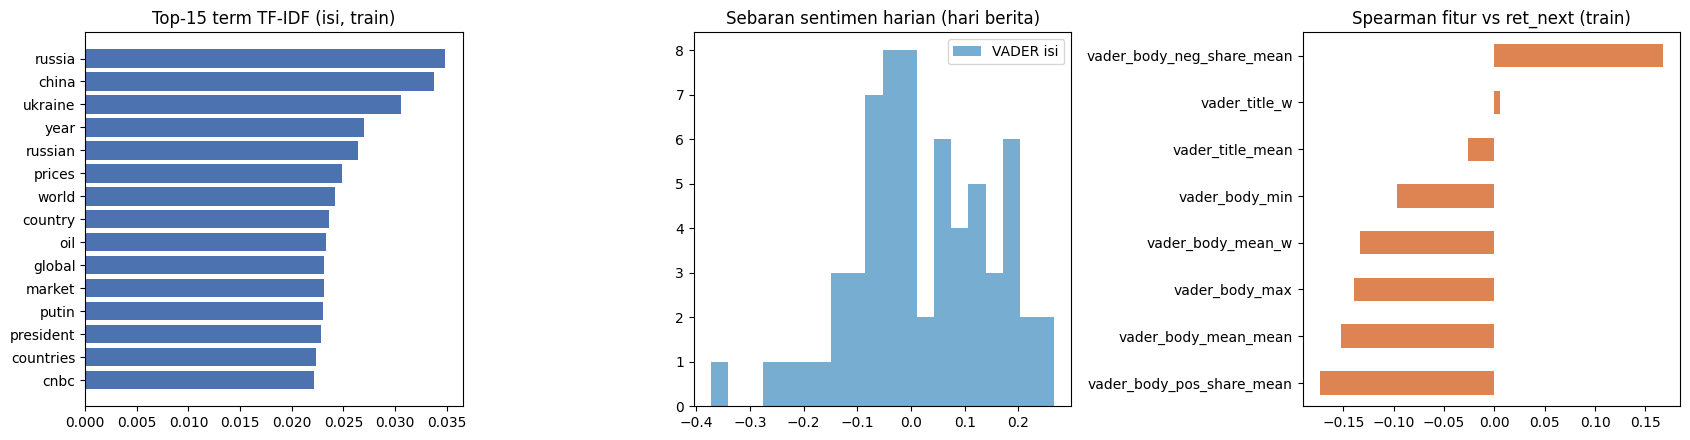

Catatan: pada sampel kecil korelasi ini hanya indikatif dan sangat rentan noise.


In [9]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

# (a) term dengan bobot TF-IDF rata-rata tertinggi (isi)
mean_w = np.asarray(X_body["train"][nz].mean(axis=0)).ravel()
top = np.argsort(mean_w)[-15:]
names = np.array(vec_body.get_feature_names_out())
ax[0].barh(names[top], mean_w[top], color="#4C72B0"); ax[0].set_title("Top-15 term TF-IDF (isi, train)")

# (b) sebaran sentimen harian (hari berita)
tn = train_f[train_f["has_news"] == 1]
ax[1].hist(tn["vader_body_mean_mean"], bins=20, alpha=.6, label="VADER isi")
ax[1].set_title("Sebaran sentimen harian (hari berita)"); ax[1].legend()

# (c) korelasi Spearman fitur sentimen vs target (hanya hari berita, train)
targets = ["log_ret", "ret_next"]
cor = tn[SENT_FEATURES + targets].corr(method="spearman")[targets].drop(targets).sort_values("ret_next")
cor["ret_next"].tail(12).plot.barh(ax=ax[2], color="#DD8452")
ax[2].set_title("Spearman fitur vs ret_next (train)")
plt.tight_layout(); plt.show()
print("Catatan: pada sampel kecil korelasi ini hanya indikatif dan sangat rentan noise.")

## 7. Simpan fitur & artefak

In [10]:
DROP_TEXT = ["text_title", "text_body"] 
for name, df in [("train", train_f), ("val", val_f), ("test", test_f)]:
    df.drop(columns=DROP_TEXT).to_csv(OUT / f"features_{name}.csv", index=False)
    sp.save_npz(OUT / f"tfidf_body_{name}.npz", X_body[name].tocsr())
    sp.save_npz(OUT / f"tfidf_title_{name}.npz", X_title[name].tocsr())

joblib.dump(vec_body, OUT / "artifacts" / "tfidf_body_vectorizer.joblib")
joblib.dump(vec_title, OUT / "artifacts" / "tfidf_title_vectorizer.joblib")
joblib.dump(svd_body, OUT / "artifacts" / "svd_body.joblib")
joblib.dump(svd_title, OUT / "artifacts" / "svd_title.joblib")

print("Ukuran tabel fitur:", {n: d.drop(columns=DROP_TEXT).shape for n, d in [("train", train_f), ("val", val_f), ("test", test_f)]})
print("Tersimpan di:", OUT)
train_f.drop(columns=DROP_TEXT).head(3)

Ukuran tabel fitur: {'train': (152, 64), 'val': (18, 64), 'test': (20, 64)}
Tersimpan di: d:\Kuliah\Tugas dan Projek\Pemrosesan Bahasa Alami\repo\nlp-trio-bertiga\data\features


,date,rate,log_ret,direction,ret_next,direction_next,gap_days,dayofweek,n_articles,mean_hours_to_cutoff,has_news,vader_title_mean,vader_body_mean_mean,vader_body_neg_share_mean,vader_body_pos_share_mean,vader_title_w,vader_body_mean_w,vader_body_min,vader_body_max,tfidf_body_svd_0,tfidf_body_svd_1,tfidf_body_svd_2,tfidf_body_svd_3,tfidf_body_svd_4,tfidf_body_svd_5,...,tfidf_body_svd_20,tfidf_body_svd_21,tfidf_body_svd_22,tfidf_body_svd_23,tfidf_body_svd_24,tfidf_body_svd_25,tfidf_body_svd_26,tfidf_body_svd_27,tfidf_body_svd_28,tfidf_body_svd_29,tfidf_title_svd_0,tfidf_title_svd_1,tfidf_title_svd_2,tfidf_title_svd_3,tfidf_title_svd_4,tfidf_title_svd_5,tfidf_title_svd_6,tfidf_title_svd_7,tfidf_title_svd_8,tfidf_title_svd_9,tfidf_title_svd_10,tfidf_title_svd_11,tfidf_title_svd_12,tfidf_title_svd_13,tfidf_title_svd_14
0,2021-09-02,14281,-0.000210,0.0,-0.001401,0.0,1.0,3,1,6.337778,1,0.0,0.165157,0.1,0.433333,0.0,0.165157,0.165157,0.165157,0.260341,0.252106,0.003101,-0.21836,0.165863,-0.388989,...,-0.070045,-0.016808,0.094806,0.100092,-0.091889,-0.08144,0.060564,-0.087458,-0.054027,0.095674,0.162939,0.211051,0.441782,-0.415161,-0.090624,-0.07215,-0.036837,-0.146353,-0.226365,-0.230632,0.130133,0.009667,-0.102858,-0.181821,-0.039657
1,2021-09-03,14261,-0.001401,0.0,-0.001544,0.0,1.0,4,0,0.000000,0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,2021-09-06,14239,-0.001544,0.0,-0.003095,0.0,3.0,0,0,0.000000,0,0.0,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


### Catatan:
- TF-IDF & SVD difit pada train; VADER/LM berbasis kamus sehingga tidak perlu fit.
- Baris `features_*.csv` sejajar dengan baris di `tfidf_*_{split}.npz`.
- Untuk model baseline time-series, fitur lag kurs dihitung dari `rate` di skrip `src/` dan dijalankan **persplit secara berurutan** .
- Kandidat fitur gabungan paling ringkas: `has_news`, `n_articles`, `gap_days`, `*_w` (sentimen berbobot), `lm_body_unc_mean`, dan komponen `tfidf_*_svd_*`.